# House Prices Project - Ames Housing Dataset 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Data loading and initial feature split

This section loads the dataset and separates the target variable from the explanatory variables.

In [3]:
X = df.drop(columns=["Id","SalePrice"])
y = df["SalePrice"]

categorical_features = X.select_dtypes(include=['str'])
numerical_features = X.select_dtypes(include = ['int64','float64'])

categorical_features_list = categorical_features.columns.tolist()
numerical_features_list = numerical_features.columns.tolist()

print("Categorical features:", len(categorical_features_list))
print(categorical_features_list)

print("Numerical features:", len(numerical_features_list))
print(numerical_features_list)

Categorical features: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numerical features: 36
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'G

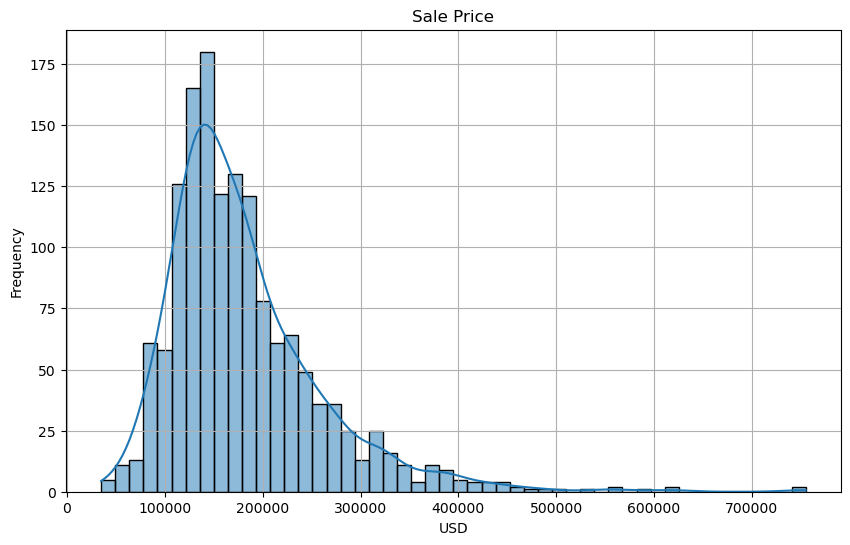

In [4]:
plt.figure(figsize=(10,6))
sns.histplot(df['SalePrice'], bins=50, kde=True)
plt.title('Sale Price')
plt.xlabel("USD")
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

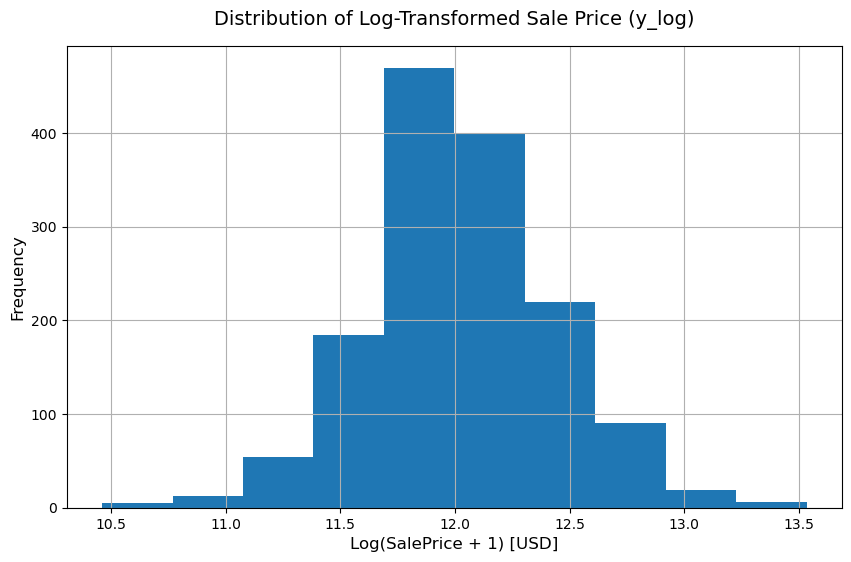

In [5]:
# Apply a logarithmic transformation to SalePrice.
# This reduces skewness and makes the target variable easier for regression models to learn.

y = np.log1p(y)
y.hist(figsize=(10,6))

plt.title('Distribution of Log-Transformed Sale Price (y_log)', fontsize=14, pad=15)
plt.xlabel('Log(SalePrice + 1) [USD]', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(True)
plt.show()

In [6]:
numerical_features.hist(bins=50, figsize=(30, 20))
plt.tight_layout()
plt.savefig("histograms_house-prices.pdf", format = "pdf")
plt.close()

In [7]:
statistics = numerical_features.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
display(statistics.round(2))

,count,mean,std,min,1%,25%,50%,75%,99%,max
MSSubClass,1460.0,56.90,42.30,20.0,20.00,20.00,50.0,70.00,190.00,190.0
LotFrontage,1201.0,70.05,24.28,21.0,21.00,59.00,69.0,80.00,141.00,313.0
LotArea,1460.0,10516.83,9981.26,1300.0,1680.00,7553.50,9478.5,11601.50,37567.64,215245.0
OverallQual,1460.0,6.10,1.38,1.0,3.00,5.00,6.0,7.00,10.00,10.0
OverallCond,1460.0,5.58,1.11,1.0,3.00,5.00,5.0,6.00,9.00,9.0
YearBuilt,1460.0,1971.27,30.20,1872.0,1899.18,1954.00,1973.0,2000.00,2009.00,2010.0
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1950.00,1967.00,1994.0,2004.00,2009.00,2010.0
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.00,0.0,166.00,791.92,1600.0
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,0.00,383.5,712.25,1572.41,5644.0
BsmtFinSF2,1460.0,46.55,161.32,0.0,0.00,0.00,0.0,0.00,830.38,1474.0


In [8]:
for column in categorical_features.columns:
    percentage_share = (categorical_features[column].value_counts(normalize=True) * 100).round(2)
    distribution_table = pd.DataFrame({'Share (%)': percentage_share})
    print(f"\n--- Feature: {column} ---")
    display(distribution_table.style.bar(vmin=0, vmax=100, color='lightblue').format("{:.2f}%"))


--- Feature: MSZoning ---


,Share (%)
MSZoning,
RL,78.84%
RM,14.93%
FV,4.45%
RH,1.10%
C (all),0.68%



--- Feature: Street ---


,Share (%)
Street,
Pave,99.59%
Grvl,0.41%



--- Feature: Alley ---


...

,Share (%)
MiscFeature,
Shed,90.74%
Gar2,3.70%
Othr,3.70%
TenC,1.85%



--- Feature: SaleType ---


,Share (%)
SaleType,
WD,86.78%
New,8.36%
COD,2.95%
ConLD,0.62%
ConLI,0.34%
ConLw,0.34%
CWD,0.27%
Oth,0.21%
Con,0.14%



--- Feature: SaleCondition ---


,Share (%)
SaleCondition,
Normal,82.05%
Partial,8.56%
Abnorml,6.92%
Family,1.37%
Alloca,0.82%
AdjLand,0.27%


In [9]:
# Remove columns with very low variability, many zero values or limited predictive value.
# These features may add noise and make the model more complex without improving prediction quality.

X = X.drop(columns = ['Street',
'Utilities',
'Condition2',
'RoofMatl',
'BsmtFinSF2',
'LowQualFinSF',
'BsmtHalfBath',
'KitchenAbvGr',
'EnclosedPorch',
'3SsnPorch',
'ScreenPorch',
'PoolArea',
'MiscVal'])

## Initial feature reduction

This section removes columns with low analytical value or very limited variability.


In [10]:
categorical_features = X.select_dtypes(include=['str'])
numerical_features = X.select_dtypes(include = ['int64','float64'])

categorical_features_list = categorical_features.columns.tolist()
numerical_features_list = numerical_features.columns.tolist()

print("Categorical features:", len(categorical_features_list))
print(categorical_features_list)

print("Numerical features:", len(numerical_features_list))
print(numerical_features_list)

Categorical features: 39
['MSZoning', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numerical features: 27
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'MoSold', 'YrSold']


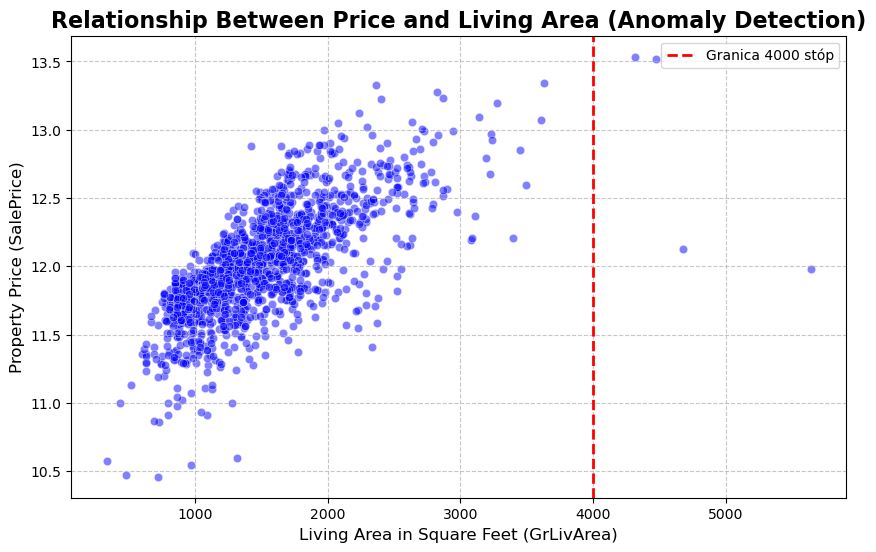

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=X['GrLivArea'], y=y, alpha=0.5, color = 'blue')
plt.axvline(x=4000, color='red', linestyle='--', linewidth=2, label='Granica 4000 stóp')
plt.title('Relationship Between Price and Living Area (Anomaly Detection)', fontsize=16, fontweight='bold')
plt.xlabel('Living Area in Square Feet (GrLivArea)', fontsize=12)
plt.ylabel('Property Price (SalePrice)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

In [12]:
# Remove observations where GrLivArea is greater than 4000.
# These cases are treated as outliers because their size is not consistent with their sale price.

anomalies = (X['GrLivArea'] > 4000)
print(f"Liczba wykrytych anomalii (> 4000): {anomalies.sum()}")
X = X[~anomalies]
y = y[~anomalies]

Liczba wykrytych anomalii (> 4000): 4


In [13]:
defect_percentage_X = (X.isnull().sum()/len(df))*100
defect_percentage_X = defect_percentage_X[defect_percentage_X>0].round(2).sort_values(ascending=False)
table_defect_X = pd.DataFrame(defect_percentage_X, columns = ['Missing values X (%)'])
table_defect_X.style.background_gradient(cmap = 'Reds', vmin = 0, vmax = 100)
print("Missing values y:",y.isnull().sum())
table_defect_X.style.background_gradient(cmap='Reds', vmin=0, vmax=100).format("{}%")

Missing values y: 0


,Missing values X (%)
PoolQC,99.38%
MiscFeature,96.03%
Alley,93.49%
Fence,80.55%
MasVnrType,59.66%
FireplaceQu,47.26%
LotFrontage,17.74%
GarageType,5.55%
GarageYrBlt,5.55%
GarageFinish,5.55%


## Missing value handling

This section identifies and fills missing values.  
Some missing values are interpreted as a real absence of a feature, for example no garage, no basement or no fireplace.

In [14]:
# Drop columns with a very high number of missing values.
# These variables contain too little useful information for reliable modeling.
# Fill missing GarageYrBlt values with YearBuilt, assuming that the garage was built around the same time as the house.
# Fill missing MasVnrArea values with 0, because missing masonry veneer area is interpreted as no masonry veneer.
# Replace missing categorical values with 'None' when missing means that the feature does not exist.
# Fill missing LotFrontage values with the median value within each neighborhood.
# Fill the missing Electrical value with the most frequent category.

columns_to_drop_now = ['PoolQC', 'MiscFeature', 'Alley']
X = X.drop(columns=columns_to_drop_now)
X['GarageYrBlt'] = X['GarageYrBlt'].fillna(X['YearBuilt'])
X['MasVnrArea'] = X['MasVnrArea'].fillna(0)
cols_none = [
    'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 
    'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType2', 
    'BsmtQual', 'BsmtCond', 'BsmtFinType1', 'MasVnrType'
]
for col in cols_none:
    X[col] = X[col].fillna('None')

X['LotFrontage'] = X.groupby('Neighborhood')['LotFrontage'].transform(lambda val: val.fillna(val.median()))
X['Electrical'] = X['Electrical'].fillna(X['Electrical'].mode()[0])

print(f"Number of missing values in matrix X after cleaning: {X.isnull().sum().sum()}")

Number of missing values in matrix X after cleaning: 0


## Ordinal encoding and correlation analysis

This section converts ordered quality categories into numerical values and checks relationships between variables.

In [15]:
# Convert ordinal quality variables into numerical values.
# Higher values represent better quality, while 0 represents missing or non-existing elements.
# Convert CentralAir into a binary variable where Y = 1 and N = 0.

print(f"Original number of features in X: {X.shape[1]}")
quality_mapper = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

ordinal_columns = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond'
]

for col in ordinal_columns:
    X[col] = X[col].replace(quality_mapper).astype(int)

X['CentralAir'] = X['CentralAir'].replace({'Y': 1, 'N': 0}).astype(int)

print(f"Number of features after Ordinal Encoding: {X.shape[1]}")

Original number of features in X: 63
Number of features after Ordinal Encoding: 63


In [16]:
numerical_features = X.select_dtypes(include = ['int64','float64'])
num_with_target = numerical_features.copy()
num_with_target['SalePrice_Log'] = y
full_corr_matrix = num_with_target.corr()
target_corr = full_corr_matrix['SalePrice_Log'].sort_values(ascending=False)[1:]
noise = target_corr[abs(target_corr) < 0.10]
print(noise.round(2) if not noise.empty else "No significant noise detected!")

plt.figure(figsize=(20, 18)) 
sns.heatmap(
    full_corr_matrix, 
    cmap='coolwarm',
    annot=True,
    vmin=-1, vmax=1, 
    fmt=".2f",                         
)
plt.title("Correlation Matrix")
plt.savefig("Ames_Correlation_Matrix.pdf", format='pdf', bbox_inches='tight')

plt.close()


MoSold         0.06
ExterCond      0.05
YrSold        -0.03
OverallCond   -0.04
MSSubClass    -0.08
Name: SalePrice_Log, dtype: float64


In [17]:
# Remove features from pairs of strongly correlated variables.
# This reduces multicollinearity and helps keep the model simpler.
# Remove low-signal features with target correlation below 0.1.
# These variables are unlikely to improve model performance and may add noise.

X = X.drop(columns = [
    # Dropped features from highly correlated feature pairs:
    'GarageArea', 
    'GarageCond', 
    'TotRmsAbvGrd', 
    'GarageYrBlt', 
    'Fireplaces',
    
    # Low-signal features (correlation with the target < 0.1):
    'YrSold', 
    'MoSold', 
    'MSSubClass', 
    'OverallCond', 
    'ExterCond'
])

## Feature selection

This section removes highly correlated or low-signal variables and uses statistical feature selection for encoded categorical variables

In [18]:
X_copy = X.copy()

In [19]:
# Apply One-Hot Encoding to categorical variables.
# This converts text categories into numerical columns that can be used by machine learning models.
# Select the best categorical features using SelectKBest and the f_regression score.
# This keeps only the most useful encoded categorical variables and reduces dimensionality.

X_cat = X_copy.select_dtypes(include=['str']) 
X_num = X_copy.select_dtypes(include=['int64', 'float64', 'int32'])

X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

selector = SelectKBest(score_func=f_regression, k=65)
X_cat_filtered_array = selector.fit_transform(X_cat_encoded, y)

surviving_cols = X_cat_encoded.columns[selector.get_support()]
X_cat_optimized = pd.DataFrame(
    X_cat_filtered_array, 
    columns=surviving_cols, 
    index=X.index 
)

In [20]:
print(f"Number of features after Ordinal Encoding: {X_copy.shape[1]}")

X = pd.concat([X_num, X_cat_optimized], axis=1)

print(f"Number of features after One-Hot Encoding: {X.shape[1]}")

Number of features after Ordinal Encoding: 53
Number of features after One-Hot Encoding: 92


## Baseline model

This section trains the first regression model and uses it as a reference point for later models.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Split the data into training and testing sets.
# The training set is used to fit the model, while the test set is used to evaluate generalization.
# random_state=42 ensures that the split is reproducible.
# Train a baseline Linear Regression model as a simple reference point.
# Evaluate it using R² on both training and test data.

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

y_pred_train = baseline_model.predict(X_train)
y_pred_test = baseline_model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train R^2: {r2_train:.4f}")
print(f"Test R^2:  {r2_test:.4f}")

Train R^2: 0.9206
Test R^2:  0.8962


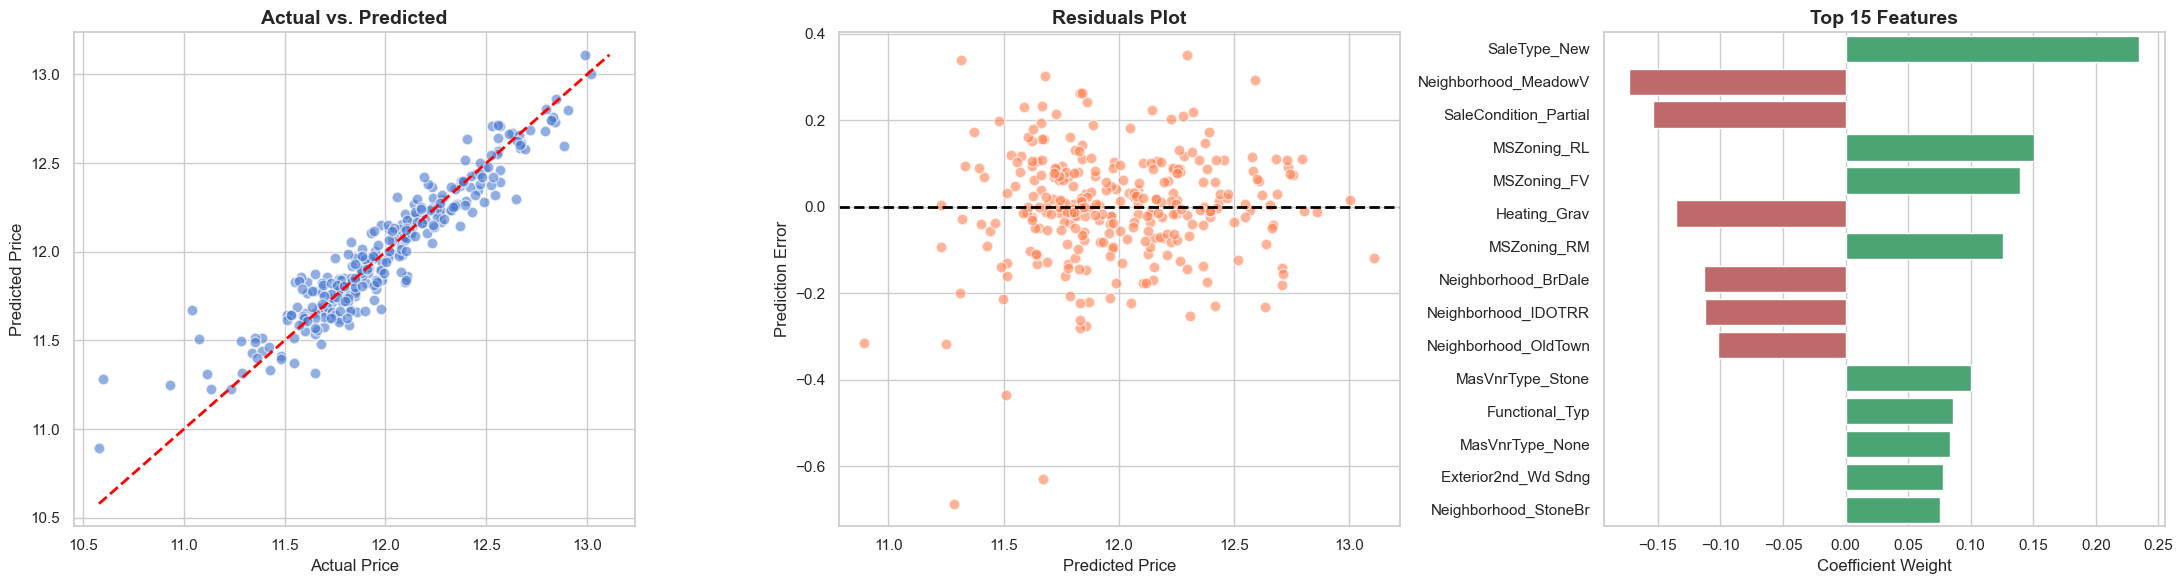

In [23]:
# Visualize the baseline Linear Regression model results.
# The first plot compares actual and predicted prices.
# The second plot shows residuals, which are the prediction errors.
# The third plot presents the 15 most influential features based on coefficient weights.
# This helps evaluate both prediction quality and model interpretability.

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].scatter(y_test, y_pred_test, alpha=0.6, edgecolors='w', s=60)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

axes[0].set_title('Actual vs. Predicted', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Price', fontsize=12)
axes[0].set_ylabel('Predicted Price', fontsize=12)

residuals = y_test - y_pred_test

axes[1].scatter(y_pred_test, residuals, alpha=0.6, color='coral', edgecolors='w', s=60)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2)

axes[1].set_title('Residuals Plot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Price', fontsize=12)
axes[1].set_ylabel('Prediction Error', fontsize=12)

coefficients = baseline_model.coef_
features = X_train.columns

coef_df = pd.DataFrame({'Feature': features, 'Weight': coefficients})
coef_df['Abs_Weight'] = coef_df['Weight'].abs()
top_features = coef_df.sort_values(by='Abs_Weight', ascending=False).head(15)

colors = ['mediumseagreen' if w > 0 else 'indianred' for w in top_features['Weight']]

sns.barplot(
    data=top_features, 
    x='Weight', 
    y='Feature', 
    ax=axes[2], 
    palette=colors,
    hue='Feature',
    legend=False
)

axes[2].set_title('Top 15 Features', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Coefficient Weight', fontsize=12)
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig("baseline-model.pdf", format = "pdf")
plt.show()


## Pipeline model comparison.

This section compares three regression models: Linear Regression, Decision Tree and KNN.  
Each model is trained on the same training data and evaluated using R² on both training and test sets.



In [24]:
# Define regression pipelines for model comparison.
# Linear Regression and KNN use StandardScaler because they are sensitive to feature scale.
# Decision Tree does not require scaling because it splits data based on feature thresholds.
# random_state=42 is used in Decision Tree to make the results reproducible.
# Each model is trained on the same training set and evaluated using R² on train and test data.
# The comparison helps identify overfitting, underfitting and generalization quality.

pipelines = {
    'Linear_Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
            
    'Decision_Tree': Pipeline([
        ('model', DecisionTreeRegressor(random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=5))
    ])
}

results = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    results[name] = {
        'Train_R2': r2_train,
        'Test_R2': r2_test
    }

for name, metrics in results.items():
    print(f"--- {name} ---")
    print(f"Train R^2: {metrics['Train_R2']:.4f}")
    print(f"Test R^2:  {metrics['Test_R2']:.4f}\n")


--- Linear_Regression ---
Train R^2: 0.9206
Test R^2:  0.8962

--- Decision_Tree ---
Train R^2: 1.0000
Test R^2:  0.6542

--- KNN ---
Train R^2: 0.8522
Test R^2:  0.7734



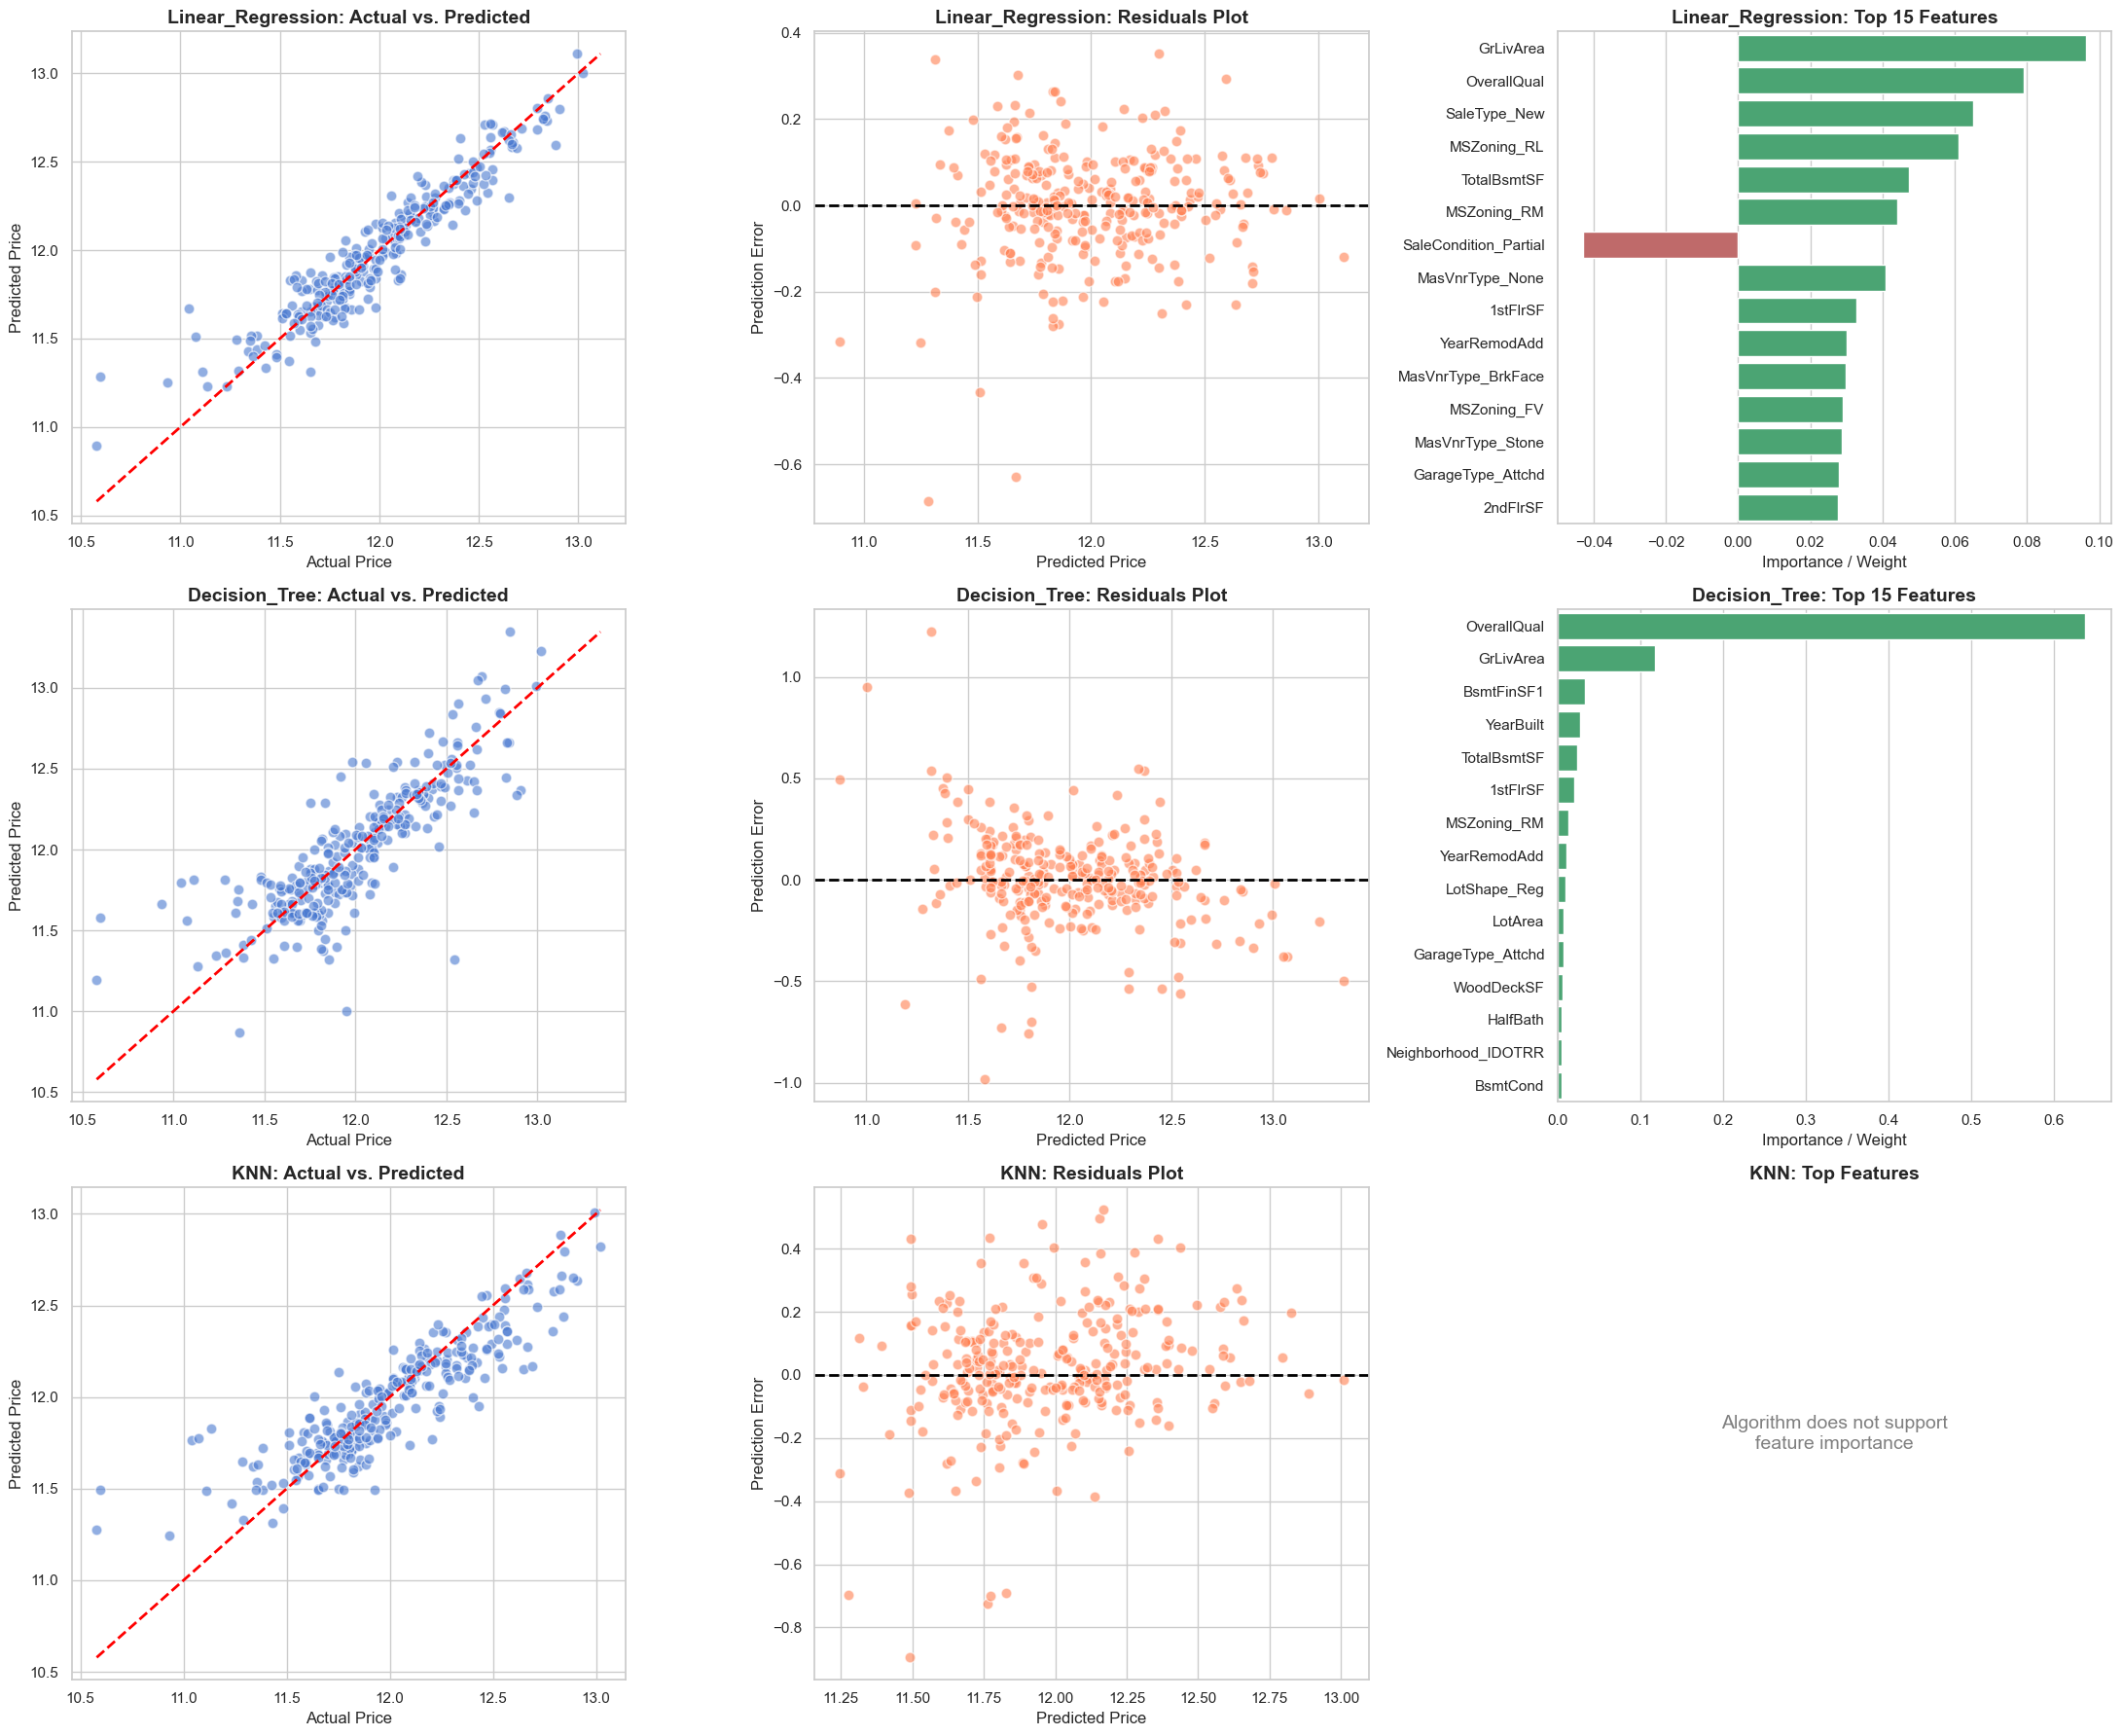

In [25]:
# Visualize prediction results for all pipeline models.
# The first plot compares actual and predicted prices.
# The second plot shows residuals, which are the differences between actual and predicted values.
# The third plot shows feature importance or coefficient weights if the model supports it.
# KNN does not provide direct feature importance, because it is based on distances between observations.
# These plots help compare model accuracy, error distribution and interpretability.

sns.set_theme(style="whitegrid", palette="muted")

num_models = len(pipelines)
fig, axes = plt.subplots(num_models, 3, figsize=(22, 6 * num_models))

for i, (model_name, pipeline) in enumerate(pipelines.items()):
    y_pred = pipeline.predict(X_test)
    
    axes[i, 0].scatter(y_test, y_pred, alpha=0.6, edgecolors='w', s=60)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[i, 0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
    axes[i, 0].set_title(f'{model_name}: Actual vs. Predicted', fontsize=14, fontweight='bold')
    axes[i, 0].set_xlabel('Actual Price', fontsize=12)
    axes[i, 0].set_ylabel('Predicted Price', fontsize=12)
    
    residuals = y_test - y_pred
    
    axes[i, 1].scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='w', s=60)
    axes[i, 1].axhline(y=0, color='black', linestyle='--', linewidth=2)
    axes[i, 1].set_title(f'{model_name}: Residuals Plot', fontsize=14, fontweight='bold')
    axes[i, 1].set_xlabel('Predicted Price', fontsize=12)
    axes[i, 1].set_ylabel('Prediction Error', fontsize=12)
    
    model_step = pipeline.named_steps['model']
    
    if hasattr(model_step, 'coef_'):
        importances = model_step.coef_
        features = X_train.columns
        is_valid = True
    elif hasattr(model_step, 'feature_importances_'):
        importances = model_step.feature_importances_
        features = X_train.columns
        is_valid = True
    else:
        is_valid = False
        
    if is_valid:
        imp_df = pd.DataFrame({'Feature': features, 'Value': importances})
        imp_df['Abs_Value'] = imp_df['Value'].abs()
        top_features = imp_df.sort_values(by='Abs_Value', ascending=False).head(15)
        
        colors = ['mediumseagreen' if val > 0 else 'indianred' for val in top_features['Value']]
        
        sns.barplot(
            data=top_features,
            x='Value',
            y='Feature',
            ax=axes[i, 2],
            palette=colors,
            hue='Feature',
            legend=False
        )
        axes[i, 2].set_title(f'{model_name}: Top 15 Features', fontsize=14, fontweight='bold')
        axes[i, 2].set_xlabel('Importance / Weight', fontsize=12)
        axes[i, 2].set_ylabel('')
    else:
        axes[i, 2].text(0.5, 0.5, 'Algorithm does not support\nfeature importance', 
                        horizontalalignment='center', verticalalignment='center', 
                        transform=axes[i, 2].transAxes, fontsize=14, color='gray')
        axes[i, 2].set_title(f'{model_name}: Top Features', fontsize=14, fontweight='bold')
        axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig("pipeline-models.pdf", format="pdf")
plt.show()

## This section trains a LassoCV regression model inside a pipeline.  
LassoCV uses L1 regularization, which helps reduce weak feature coefficients and improves model generalization.

In [26]:
X_cat = X_copy.select_dtypes(include=['str']) 
X_num = X_copy.select_dtypes(include=['int64', 'float64', 'int32'])

X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

selector = SelectKBest(score_func=f_regression, k=80)
X_cat_filtered_array = selector.fit_transform(X_cat_encoded, y)

surviving_cols = X_cat_encoded.columns[selector.get_support()]
X_cat_optimized = pd.DataFrame(
    X_cat_filtered_array, 
    columns=surviving_cols, 
    index=X.index 
)

In [27]:
print(f"Number of features after Ordinal Encoding: {X_copy.shape[1]}")

X = pd.concat([X_num, X_cat_optimized], axis=1)

print(f"Number of features after One-Hot Encoding: {X.shape[1]}")

Number of features after Ordinal Encoding: 53
Number of features after One-Hot Encoding: 107


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(cv=5, random_state=42))
])

lasso_pipeline.fit(X_train, y_train)

y_pred_train = lasso_pipeline.predict(X_train)
y_pred_test = lasso_pipeline.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("--- LassoCV ---")
print(f"Train R^2: {r2_train:.4f}")
print(f"Test R^2:  {r2_test:.4f}")

--- LassoCV ---
Train R^2: 0.9272
Test R^2:  0.9001


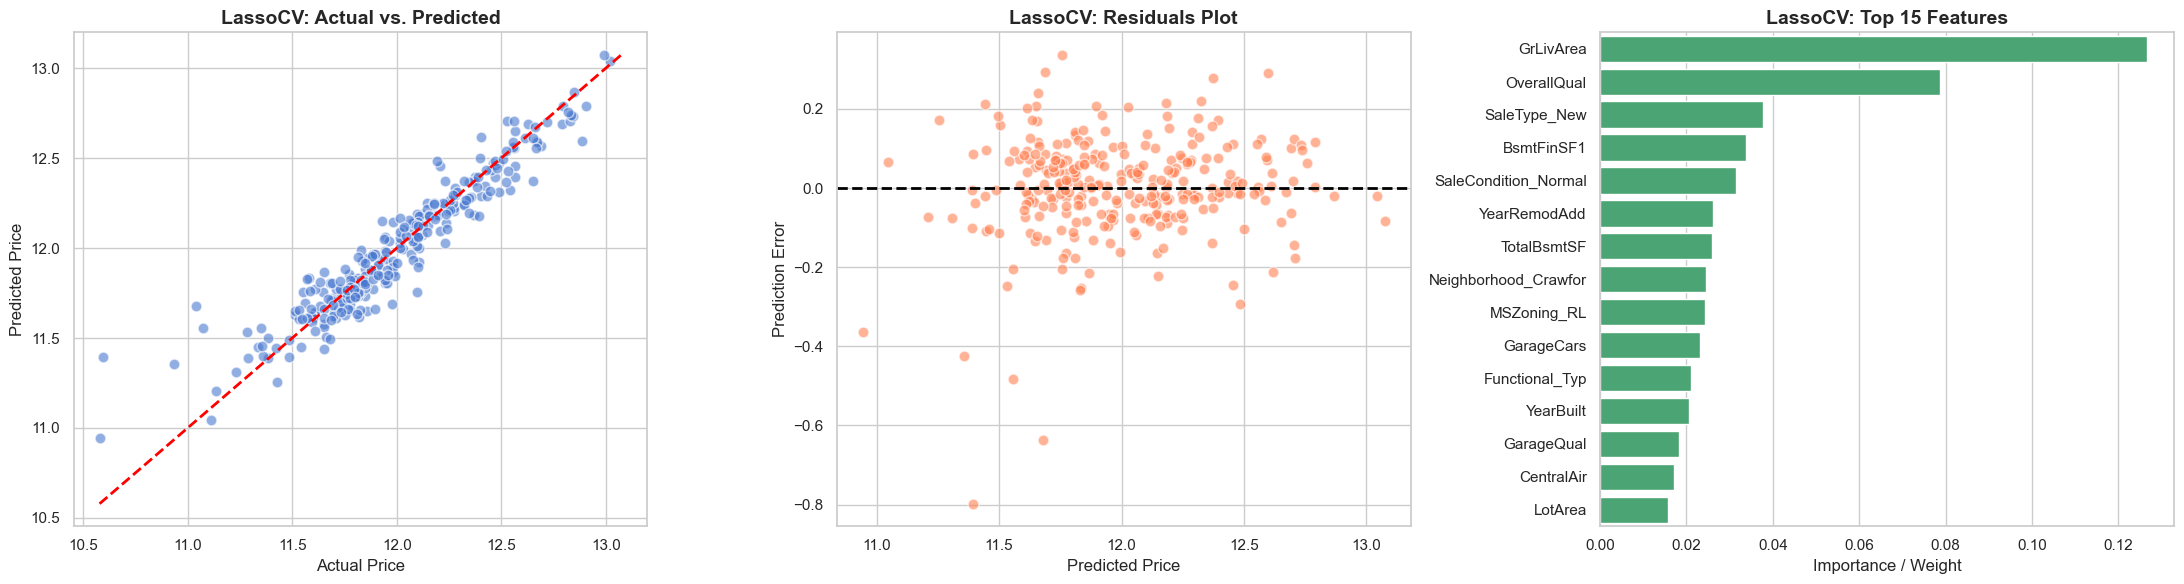

In [30]:
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

y_pred = lasso_pipeline.predict(X_test)

axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='w', s=60)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
axes[0].set_title('LassoCV: Actual vs. Predicted', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Price', fontsize=12)
axes[0].set_ylabel('Predicted Price', fontsize=12)

residuals = y_test - y_pred

axes[1].scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='w', s=60)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1].set_title('LassoCV: Residuals Plot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Price', fontsize=12)
axes[1].set_ylabel('Prediction Error', fontsize=12)

lasso_model = lasso_pipeline.named_steps['model']
importances = lasso_model.coef_
features = X_train.columns

imp_df = pd.DataFrame({'Feature': features, 'Value': importances})
imp_df['Abs_Value'] = imp_df['Value'].abs()
top_features = imp_df.sort_values(by='Abs_Value', ascending=False).head(15)

colors = ['mediumseagreen' if val > 0 else 'indianred' for val in top_features['Value']]

sns.barplot(
    data=top_features,
    x='Value',
    y='Feature',
    ax=axes[2],
    palette=colors,
    hue='Feature',
    legend=False
)
axes[2].set_title('LassoCV: Top 15 Features', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Importance / Weight', fontsize=12)
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig("lasso-pipeline.pdf", format="pdf")
plt.show()